# Task 1 — Load, Explore, Visualize, and Clip Baseline Spatial Data

Converted from `Task_1_Clip_Visualize.py` on 2025-12-29 05:37:04.

This notebook is structured so you get **visible outputs at every step** (prints + plots). Set your input paths in the **Config** cell and run top-to-bottom.


## 1) Library imports

In [12]:

import os
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import matplotlib.pyplot as plt
from rasterio.enums import Resampling

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2) User inputs (Edit this cell)
Update your `country_boundary` and `folders` paths here. You can keep `OVERWRITE=False` to avoid re-processing.

In [14]:

# Path to boundary shapefile (country / basin boundary)
country_boundary = r"E:\VUB\Final\Boundaries\EU_Country_New.shp"

# Folder paths containing raster .tif files
folders = [
    r"E:\VUB\Final\AET",
    r"E:\VUB\Final\LULC",
    r"E:\VUB\Final\Precipitation",
    r"E:\VUB\Final\RootZoneSoilMoisture",
    r"E:\VUB\Final\Soil",
    r"E:\VUB\Final\Temperature_Mean"
]

SUFFIX = "_clipped"
OVERWRITE = False

# Plot + stats output directory (created next to your first folder's parent)
# Example: if first folder is E:\VUB\Final\AET, then plots go to E:\VUB\Final\Layer_Plots
PLOT_MAX_PER_FOLDER = 10  # number of rasters to plot from each folder

print("Boundary:", country_boundary)
print("Folders:")
for f in folders:
    print(" -", f)
print("SUFFIX:", SUFFIX, "| OVERWRITE:", OVERWRITE, "| PLOT_MAX_PER_FOLDER:", PLOT_MAX_PER_FOLDER)


Boundary: E:\VUB\Final\Boundaries\EU_Country_New.shp
Folders:
 - E:\VUB\Final\AET
 - E:\VUB\Final\LULC
 - E:\VUB\Final\Precipitation
 - E:\VUB\Final\RootZoneSoilMoisture
 - E:\VUB\Final\Soil
 - E:\VUB\Final\Temperature_Mean
SUFFIX: _clipped | OVERWRITE: False | PLOT_MAX_PER_FOLDER: 10


## 3) Pre-clip input check: quick plots + stats
This cell:
- prints CRS, size, pixel resolution, NoData, min/max and P2/P98
- saves a quicklook PNG for the first raster(s) in each folder

If a folder/path is missing, you will see a clear message (instead of a hard crash).


================= PRE-CLIP INPUT CHECK =================

--- INPUT LAYER CHECK ---
File      : E:\VUB\Final\AET\AET_2014.tif
CRS       : EPSG:4326
Size      : 3600 x 1800
PixelSize : 0.1 x 0.1
NoData    : -999.0
Min/Max   : -270.11322021484375 / 2143.579345703125
P2/P98    : 0.0 / 1625.7625122070315


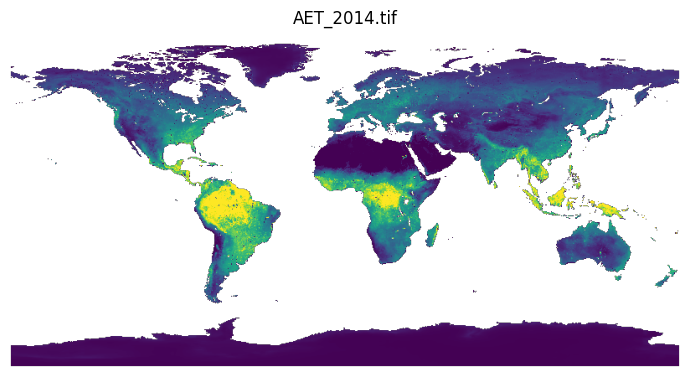

Saved plot: E:\VUB\Final\Layer_Plots\AET__AET_2014.png

--- INPUT LAYER CHECK ---
File      : E:\VUB\Final\LULC\LULC_2014_10Km.tif
CRS       : EPSG:4326
Size      : 452 x 355
PixelSize : 0.100106506329646 x 0.09988759866478873
NoData    : None
Min/Max   : 0.0 / 200.0
P2/P98    : 0.0 / 200.0


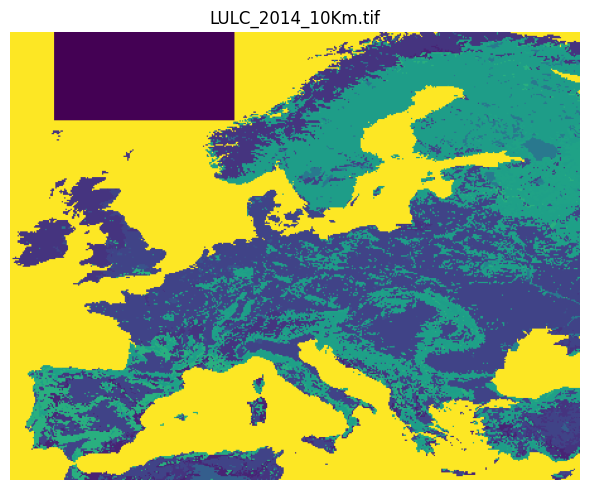

Saved plot: E:\VUB\Final\Layer_Plots\LULC__LULC_2014_10Km.png

--- INPUT LAYER CHECK ---
File      : E:\VUB\Final\Precipitation\Precipitation_2014.tif
CRS       : EPSG:4326
Size      : 911 x 381
PixelSize : 0.1 x 0.1
NoData    : None
Min/Max   : nan / nan
P2/P98    : nan / nan


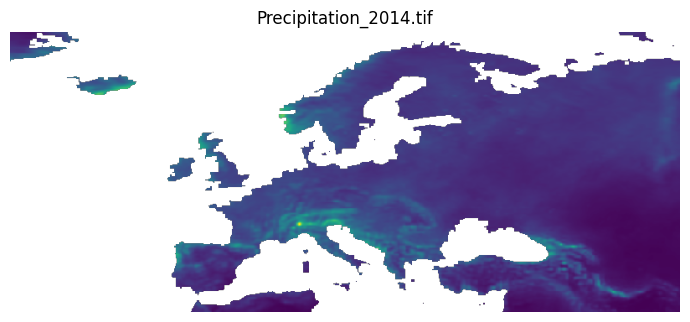

Saved plot: E:\VUB\Final\Layer_Plots\Precipitation__Precipitation_2014.png

--- INPUT LAYER CHECK ---
File      : E:\VUB\Final\RootZoneSoilMoisture\RZSM_2014.tif
CRS       : EPSG:4326
Size      : 3600 x 1800
PixelSize : 0.1 x 0.1
NoData    : -999.0
Min/Max   : 0.029999999329447746 / 0.6045961976051331
P2/P98    : 0.029999999329447746 / 0.41402530789375314


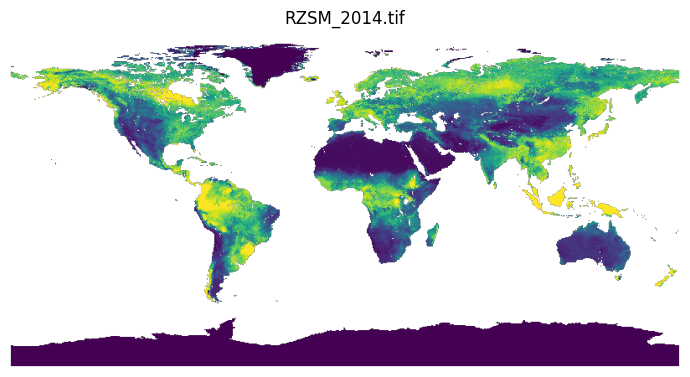

Saved plot: E:\VUB\Final\Layer_Plots\RootZoneSoilMoisture__RZSM_2014.png

--- INPUT LAYER CHECK ---
File      : E:\VUB\Final\Soil\Soil_HSG_10Km.tif
CRS       : EPSG:4326
Size      : 910 x 380
PixelSize : 0.10000914443296705 x 0.1000439548
NoData    : None
Min/Max   : 0.0 / 4.0
P2/P98    : 0.0 / 4.0


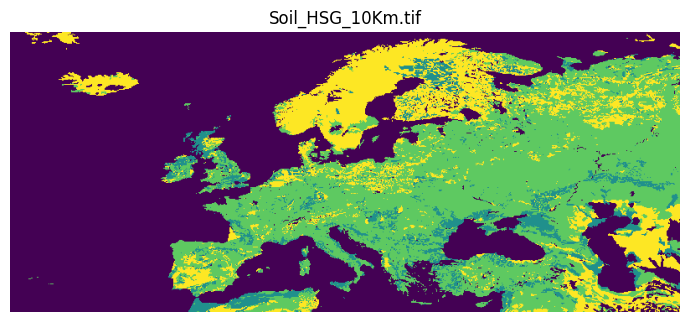

Saved plot: E:\VUB\Final\Layer_Plots\Soil__Soil_HSG_10Km.png

--- INPUT LAYER CHECK ---
File      : E:\VUB\Final\Temperature_Mean\Temperature_Mean_2014.tif
CRS       : EPSG:4326
Size      : 911 x 381
PixelSize : 0.1 x 0.1
NoData    : None
Min/Max   : nan / nan
P2/P98    : nan / nan


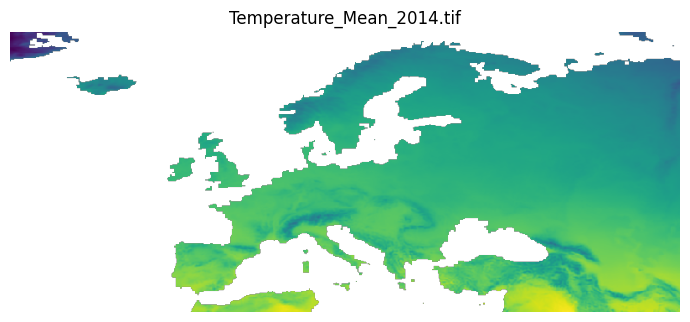

Saved plot: E:\VUB\Final\Layer_Plots\Temperature_Mean__Temperature_Mean_2014.png

Pre-clip plotting done. Plots saved at: E:\VUB\Final\Layer_Plots



In [4]:

# NEW: PLOT + STATS (BEFORE CLIPPING)

# Create plot directory next to the first folder's parent
# (safe even if folders[0] doesn't exist yet — we handle it)
base_parent = os.path.dirname(folders[0]) if folders else os.getcwd()
PLOT_DIR = os.path.join(base_parent, "Layer_Plots")
os.makedirs(PLOT_DIR, exist_ok=True)

def raster_quicklook_and_stats(raster_path: str, out_png: str):
    with rasterio.open(raster_path) as src:
        if src.crs is None:
            raise ValueError(f"Raster has no CRS defined: {raster_path}")

        # resolution (pixel size)
        px_w = float(src.transform.a)
        px_h = float(abs(src.transform.e))

        # downsample for plotting
        target = 800
        scale = max(src.width / target, src.height / target, 1.0)
        out_w = int(src.width / scale)
        out_h = int(src.height / scale)

        arr = src.read(
            1,
            masked=True,
            out_shape=(out_h, out_w),
            resampling=Resampling.nearest
        )

        # stats ignoring masked/nodata
        data = arr.compressed()
        if data.size == 0:
            vmin = vmax = p2 = p98 = np.nan
        else:
            vmin = float(np.min(data))
            vmax = float(np.max(data))
            p2 = float(np.percentile(data, 2))
            p98 = float(np.percentile(data, 98))

        print("\n--- INPUT LAYER CHECK ---")
        print("File      :", raster_path)
        print("CRS       :", src.crs)
        print("Size      :", src.width, "x", src.height)
        print("PixelSize :", px_w, "x", px_h)
        print("NoData    :", src.nodata)
        print("Min/Max   :", vmin, "/", vmax)
        print("P2/P98    :", p2, "/", p98)

        # plot (stretch using p2-p98 for continuous layers)
        plt.figure(figsize=(7, 5))
        if np.isfinite(p2) and np.isfinite(p98) and p2 != p98:
            plt.imshow(arr, vmin=p2, vmax=p98)
        else:
            plt.imshow(arr)

        plt.title(os.path.basename(raster_path))
        plt.axis("off")
        plt.tight_layout()
        plt.savefig(out_png, dpi=150)
        plt.show()  # show inline in notebook
        plt.close()

print("\n================= PRE-CLIP INPUT CHECK =================")
for folder in folders:
    try:
        if not os.path.isdir(folder):
            print(f"Folder not found, skipping: {folder}")
            continue

        tifs = [f for f in os.listdir(folder) if f.lower().endswith(".tif")]
        if not tifs:
            print(f"No tif found in: {folder}")
            continue

        tifs = sorted(tifs)[:PLOT_MAX_PER_FOLDER]

        for f in tifs:
            in_raster = os.path.join(folder, f)
            out_png = os.path.join(
                PLOT_DIR,
                f"{os.path.basename(os.path.normpath(folder))}__{os.path.splitext(f)[0]}.png"
            )
            raster_quicklook_and_stats(in_raster, out_png)
            print("Saved plot:", out_png)

    except Exception as e:
        print(f"Error while checking folder {folder}: {e}")

print("\nPre-clip plotting done. Plots saved at:", PLOT_DIR)
print("========================================================\n")


## 4) Load boundary shapefile (and dissolve)
This prints boundary CRS and feature count. It will dissolve to one geometry for clipping.

Boundary loaded.
CRS: EPSG:4326
Features: 29
Dissolved boundary. Features now: 1


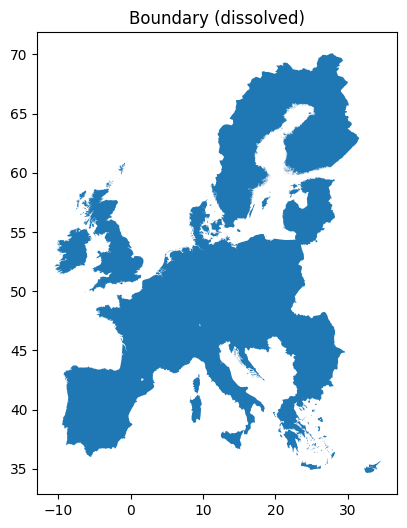

In [15]:

try:
    gdf = gpd.read_file(country_boundary)
    print("Boundary loaded.")
    print("CRS:", gdf.crs)
    print("Features:", len(gdf))

    if gdf.crs is None:
        raise ValueError("Country boundary shapefile has no CRS defined")

    gdf = gdf.dissolve()
    print("Dissolved boundary. Features now:", len(gdf))

    # quick plot
    ax = gdf.plot(figsize=(6, 6))
    ax.set_title("Boundary (dissolved)")
    plt.show()

except Exception as e:
    print("Failed to load boundary:", e)
    raise


## 5) Clip all rasters
For each input folder, this writes clipped rasters into a sibling folder named `<Param>_Clipped`.

Outputs printed for each file, so you can track progress.

In [6]:

for folder in folders:
    if not os.path.isdir(folder):
        print(f"Folder not found, skipping: {folder}")
        continue

    param_name = os.path.basename(os.path.normpath(folder))   # e.g., AET
    out_dir = os.path.join(os.path.dirname(folder), f"{param_name}_Clipped")
    os.makedirs(out_dir, exist_ok=True)

    print(f"\nProcessing folder: {folder}")
    print(f"Output folder     : {out_dir}")

    for fname in os.listdir(folder):
        if not fname.lower().endswith(".tif"):
            continue

        in_raster = os.path.join(folder, fname)
        name, ext = os.path.splitext(fname)
        out_raster = os.path.join(out_dir, f"{name}{SUFFIX}{ext}")

        if (not OVERWRITE) and os.path.exists(out_raster):
            print(f"Exists, skipping: {out_raster}")
            continue

        with rasterio.open(in_raster) as src:
            if src.crs is None:
                raise ValueError(f"Raster has no CRS defined: {in_raster}")

            # Reproject boundary to raster CRS if required
            if gdf.crs != src.crs:
                gdf_proj = gdf.to_crs(src.crs)
                geom = [gdf_proj.geometry.iloc[0]]
            else:
                geom = [gdf.geometry.iloc[0]]

            clipped, transform = mask(
                src,
                geom,
                crop=True,
                nodata=src.nodata
            )

            profile = src.profile.copy()
            profile.update(
                height=clipped.shape[1],
                width=clipped.shape[2],
                transform=transform,
                compress="lzw"
            )

            with rasterio.open(out_raster, "w", **profile) as dst:
                dst.write(clipped)

        print(f"Clipped -> {out_raster}")

print("\nAll specified folders processed successfully.")



Processing folder: E:\VUB\Final\AET
Output folder     : E:\VUB\Final\AET_Clipped
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2014_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2015_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2016_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2017_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2018_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2019_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2020_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2021_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2022_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2023_clipped.tif
Exists, skipping: E:\VUB\Final\AET_Clipped\AET_2024_clipped.tif

Processing folder: E:\VUB\Final\LULC
Output folder     : E:\VUB\Final\LULC_Clipped
Exists, skipping: E:\VUB\Final\LULC_Clipped\LULC_2014_10Km_clipped.tif
Exists, skipping: E:\VUB\Final\LULC_Clipped\LULC_2015_10Km_

## 6) Quick visual check of a clipped output (optional)
Update the path to any clipped raster you want to visually verify.

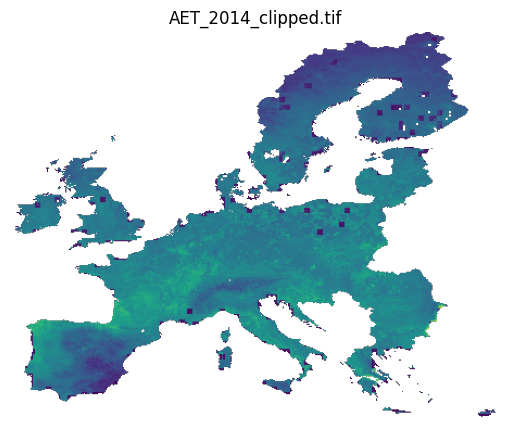

In [9]:

# Example: point to any one clipped raster to preview
example_clipped_raster = r"E:\VUB\Final\AET_Clipped\AET_2014_clipped.tif"

if example_clipped_raster and os.path.exists(example_clipped_raster):
    with rasterio.open(example_clipped_raster) as src:
        arr = src.read(1, masked=True)
        plt.figure(figsize=(7,5))
        plt.imshow(arr)
        plt.title(os.path.basename(example_clipped_raster))
        plt.axis("off")
        plt.show()
else:
    print("Set `example_clipped_raster` to a valid path to preview a clipped output.")
